In [67]:
# Install dependencies as needed:

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import pickle
# LOAD DATA
file_path = "insurance.csv"
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mirichoi0218/insurance",
    file_path,
)
print("First 5 records:\n", df.head())

df.info()
print(df.describe())
df.columns = df.columns.str.strip()

# ── 2. OUTLIER HANDLING ──────────────────────────────────────────────────────
# FIX: Insurance charges are legitimately right-skewed (high-cost patients,
# smokers, chronic illness). Removing IQR outliers discards the most
# important cases the model needs to learn. Use log-transform instead.
df['charges'] = np.log1p(df['charges'])
print("Applied log1p transform to 'charges' to handle skew.")

# ── 3. ENCODING ──────────────────────────────────────────────────────────────
df['sex']    = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

Using Colab cache for faster access to the 'insurance' dataset.
First 5 records:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
              

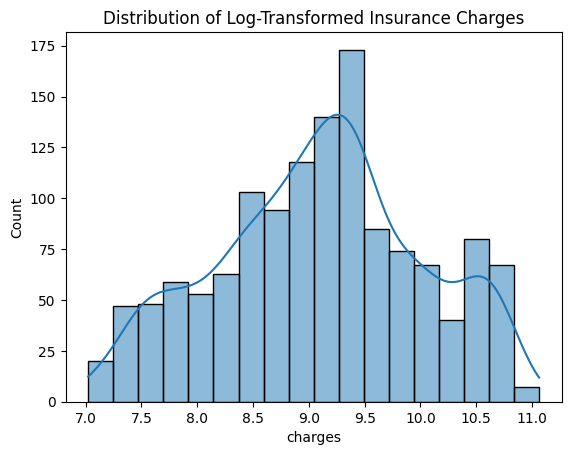

In [68]:
# ── 4. EXPLORATORY PLOTS ─────────────────────────────────────────────────────
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Log-Transformed Insurance Charges")
plt.show()




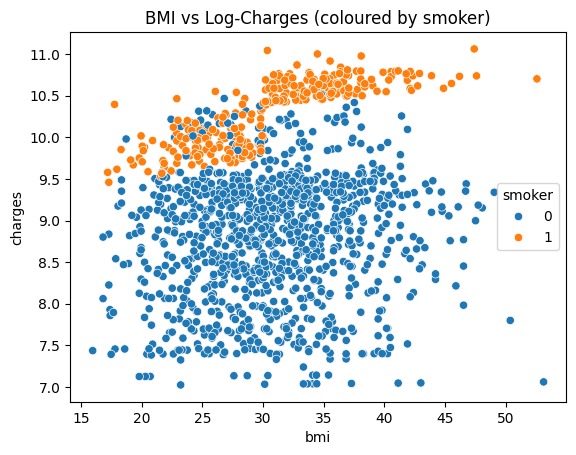

In [69]:
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Log-Charges (coloured by smoker)")
plt.show()


In [70]:
# ── 5. FEATURE ENGINEERING ───────────────────────────────────────────────────
df['bmi_smoker'] = df['bmi'] * df['smoker']
df['age_smoker'] = df['age'] * df['smoker']

X = df.drop('charges', axis=1)
y = df['charges']

In [71]:
# ── 6. TRAIN / TEST SPLIT ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 7. SCALING ───────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 8. MODELS ────────────────────────────────────────────────────────────────
model = LinearRegression()
ridge_model = Ridge(alpha=1.0)

model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)

# ── 9. PREDICTIONS ───────────────────────────────────────────────────────────
y_pred       = model.predict(X_test_scaled)
y_pred_ridge = ridge_model.predict(X_test_scaled)

# ── 10. EVALUATION ───────────────────────────────────────────────────────────
print("\n--- Linear Regression Results ---")
print("MAE:     ", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

print("\n--- Ridge Regression Results ---")
print("MAE:     ", mean_absolute_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))



--- Linear Regression Results ---
MAE:      0.19891707949412174
R2 Score: 0.8536942796233291

--- Ridge Regression Results ---
MAE:      0.19901879547388443
R2 Score: 0.8537293681973178



--- Feature Importance (Linear Regression, scaled coefficients) ---
         Feature  Coefficient
      bmi_smoker     0.677517
             age     0.581514
          smoker     0.485283
        children     0.123304
             bmi     0.006162
region_northwest    -0.027591
             sex    -0.042178
region_southeast    -0.056154
region_southwest    -0.065145
      age_smoker    -0.556637


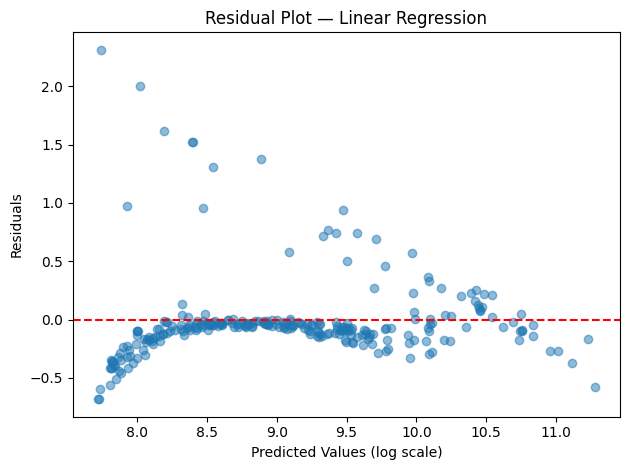

In [72]:
# ── 11. FEATURE IMPORTANCE ───────────────────────────────────────────────────
coeff_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_
})
print("\n--- Feature Importance (Linear Regression, scaled coefficients) ---")
print(coeff_df.sort_values(by='Coefficient', ascending=False).to_string(index=False))

# ── 12. RESIDUAL ANALYSIS ────────────────────────────────────────────────────
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values (log scale)")
plt.ylabel("Residuals")
plt.title("Residual Plot — Linear Regression")
plt.tight_layout()
plt.show()



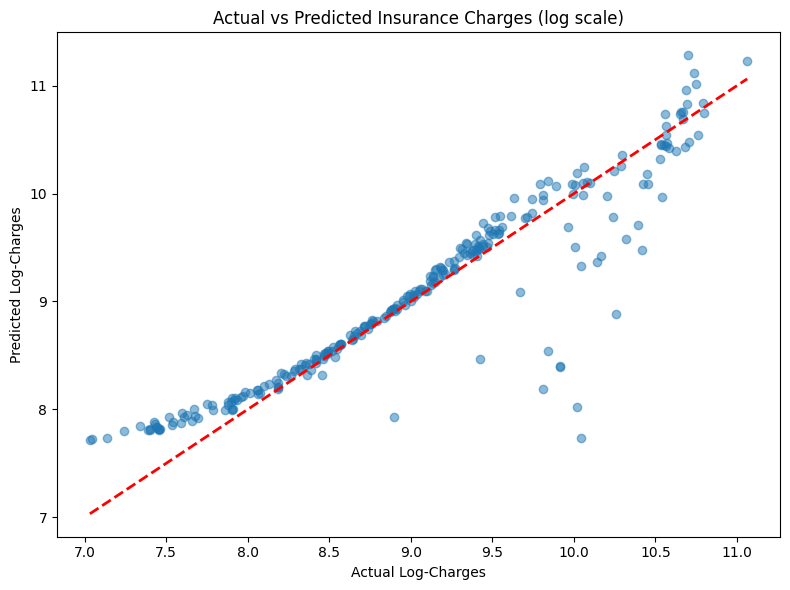

In [73]:
# ── 13. ACTUAL vs PREDICTED ──────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Log-Charges")
plt.ylabel("Predicted Log-Charges")
plt.title("Actual vs Predicted Insurance Charges (log scale)")
plt.tight_layout()
plt.show()

In [74]:
with open("linear_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("ridge_model.pkl", "wb") as f:
    pickle.dump(ridge_model, f)


print("\nModels saved successfully!")


Models saved successfully!


In [75]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)